In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter
from matplotlib.ticker import MultipleLocator

import seaborn as sns

from preprocessing.cleaner import CombustibilDataCleaner

In [3]:

combustibil = CombustibilDataCleaner()
combustibil.read_csv("merged", "combustibil_data.csv")
combustibil.reapply_types()
combustibil_data = combustibil.get_data()

In [4]:
combustibil_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   IDAlimentare        2587 non-null   int64         
 1   Furnizor            2587 non-null   category      
 2   Data                2587 non-null   datetime64[us]
 3   NumarInmatriculare  2587 non-null   category      
 4   Produs              2587 non-null   category      
 5   Cantitate           2587 non-null   float64       
 6   PretUnitar          2587 non-null   float64       
 7   Valoare             2587 non-null   float64       
 8   IDMasina            2587 non-null   int64         
dtypes: category(3), datetime64[us](1), float64(3), int64(2)
memory usage: 129.5 KB


In [5]:
combustibil_data.describe()

,IDAlimentare,Data,Cantitate,PretUnitar,Valoare,IDMasina
count,2587.000000,2587,2587.000000,2587.000000,2587.000000,2587.000000
mean,3055.288365,2025-10-24 21:18:11.311944,51.239892,6.736440,345.423129,1343.506765
min,2.000000,2025-04-01 00:00:00,1.260000,5.748000,7.563000,26.000000
25%,1369.500000,2025-07-16 04:10:30,39.020000,6.281000,255.995000,1217.000000
50%,2816.000000,2025-10-23 10:08:00,46.250000,6.570000,309.752000,1314.000000
75%,4335.500000,2026-02-05 16:45:32.500000,64.125000,6.942000,429.387250,1516.000000
max,6640.000000,2026-05-15 21:21:00,252.160000,9.198400,1661.297500,1707.000000
std,1929.807614,NaN,20.596939,0.685212,142.472698,291.568776


## Part I: Supplier and their Products

In [6]:
supplier_palette = {
    "OMV":       "#1043DD", #navy
    "Rompetrol": "#ff6929", #fire
    "Petrom":    "#f3c00a",
    "MOL":       "#E41313", 
}

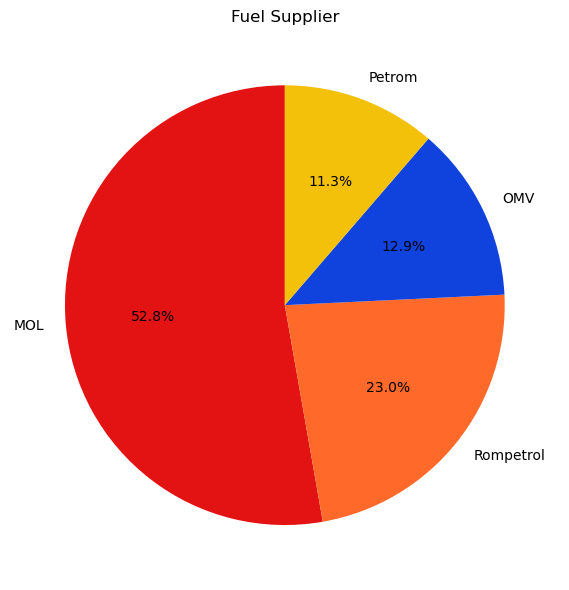

In [7]:
product_counts = combustibil_data['Furnizor'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(product_counts, labels=product_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=[supplier_palette.get(supplier, 'gray') for supplier in product_counts.index])
plt.title('Fuel Supplier')
plt.tight_layout()

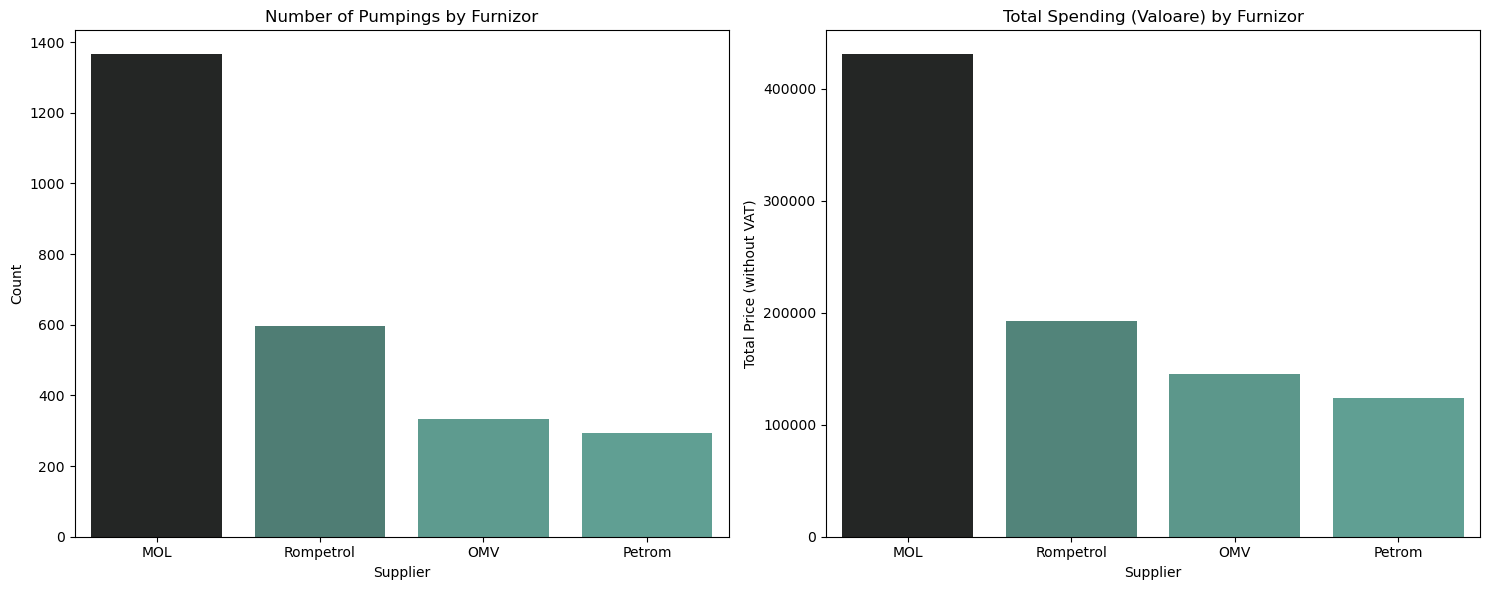

In [8]:
pumping_counts = combustibil_data['Furnizor'].value_counts().sort_values(ascending=False)
spending_by_provider = combustibil_data.groupby('Furnizor')['Valoare'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=pumping_counts.index.astype(str), y=pumping_counts.values, ax=axes[0], palette="dark:#5A9_r", hue=pumping_counts.values, legend=False)
axes[0].set_title('Number of Pumpings by Furnizor')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Supplier')

sns.barplot(x=spending_by_provider.index.astype(str), y=spending_by_provider.values, ax=axes[1], palette="dark:#5A9_r", hue=spending_by_provider.values, legend=False)
axes[1].set_title('Total Spending (Valoare) by Furnizor')
axes[1].set_ylabel('Total Price (without VAT)')
axes[1].set_xlabel('Supplier')
plt.tight_layout()


C:\Users\Tudor\AppData\Local\Temp\ipykernel_26144\2337325168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=combustibil_data, x='Furnizor', y='Cantitate', palette=supplier_palette)


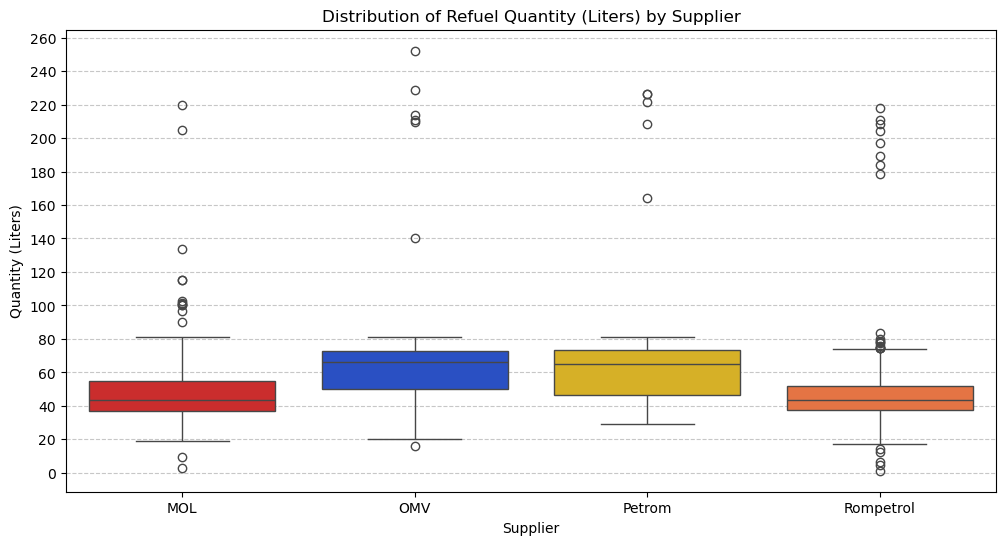

In [9]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=combustibil_data, x='Furnizor', y='Cantitate', palette=supplier_palette)
ax.yaxis.set_major_locator(MultipleLocator(20))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Distribution of Refuel Quantity (Liters) by Supplier')
plt.ylabel('Quantity (Liters)')
plt.xlabel('Supplier')
plt.show()


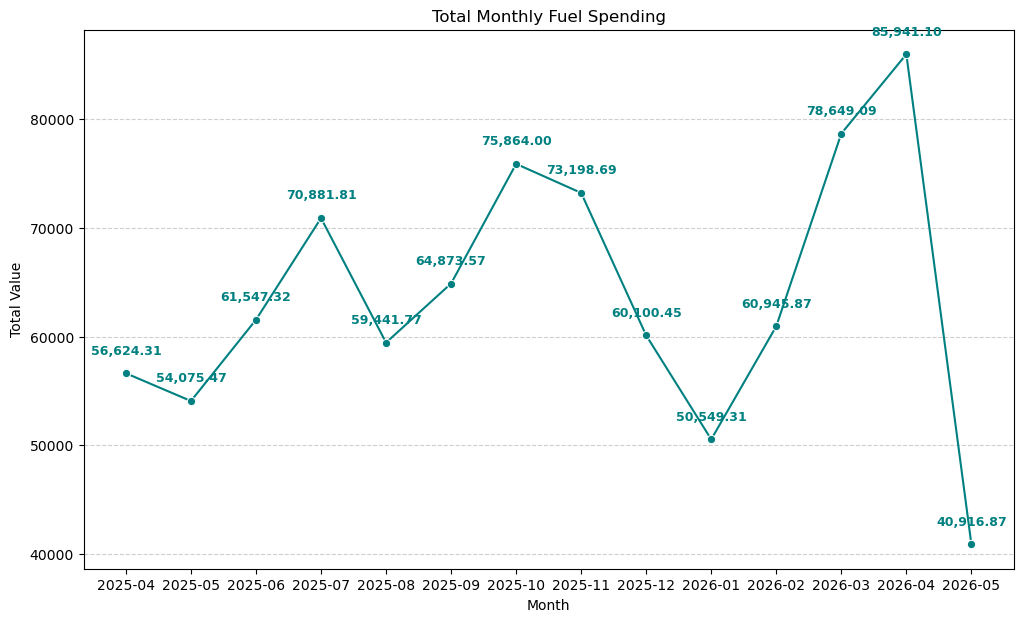

In [10]:
temp_comb_data = combustibil_data.copy()
temp_comb_data['Month'] = temp_comb_data['Data'].dt.to_period('M')
monthly_spending = temp_comb_data.groupby('Month')['Valoare'].sum().reset_index()
monthly_spending['Month_str'] = monthly_spending['Month'].astype(str)


plt.figure(figsize=(12, 7))
ax = sns.lineplot(data= monthly_spending, x='Month_str', y='Valoare', marker='o', color='teal')

for i, row in monthly_spending.iterrows():
    ax.text(i, row['Valoare'] + 1500, f"{row['Valoare']:,.2f}", 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='teal')
plt.title('Total Monthly Fuel Spending')
plt.xlabel('Month')
plt.ylabel('Total Value')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()


In [11]:
# extract the product for each supplier depending on the available cars
get_product_names = combustibil_data.groupby(['Furnizor', 'Produs']).agg({
    'Cantitate': 'sum',
    'PretUnitar': 'mean',
    'Valoare': 'sum',
    'IDAlimentare': 'count'
}).reset_index()
get_product_names.rename(columns={'IDAlimentare': 'Numar Tranzactii'}, inplace=True)
get_product_names

,Furnizor,Produs,Cantitate,PretUnitar,Valoare,Numar Tranzactii
0,MOL,Benzina Evo 95,2.77,7.355000,20.3700,1
1,MOL,Motorina Evo D,37322.86,6.564983,244812.7900,825
2,MOL,Motorina Evo D Plus,27140.97,6.849677,186013.0000,539
3,OMV,OMV Diesel,13452.77,6.596620,88641.8780,215
4,OMV,OMV MM Diesel,4478.74,7.239669,32339.4448,68
5,OMV,OMV MM Diesel Artic,3356.87,7.314690,24519.2300,50
6,OMV,OMV MMotion95,19.98,6.025500,120.3900,1
7,Petrom,Motorina Extra,5533.36,6.967359,38629.0246,91
8,Petrom,Motorina standard,13028.04,6.590848,85633.6238,202
9,Rompetrol,EFIX MOTORINA 51,18806.03,6.767948,127340.5198,381


In [12]:
# average daily price comparison: standard diesel products


def plot_price_comparison(df, title_suffix=""):
    temp_price_comparison = df.groupby(
            ['Furnizor', df['Data'].dt.date]
        )['PretUnitar'].mean().reset_index()

    temp_price_comparison['Data'] = pd.to_datetime(temp_price_comparison['Data'])


    plt.figure(figsize=(12, 6))
    ax = sns.lineplot(data=temp_price_comparison, x='Data', y='PretUnitar', hue='Furnizor', palette=supplier_palette)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%b\n%Y'))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))

    plt.title(f'Average Daily Price Comparison: {title_suffix} Diesel Products')
    plt.ylabel('Price per Liter (No VAT)')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    plt.show()

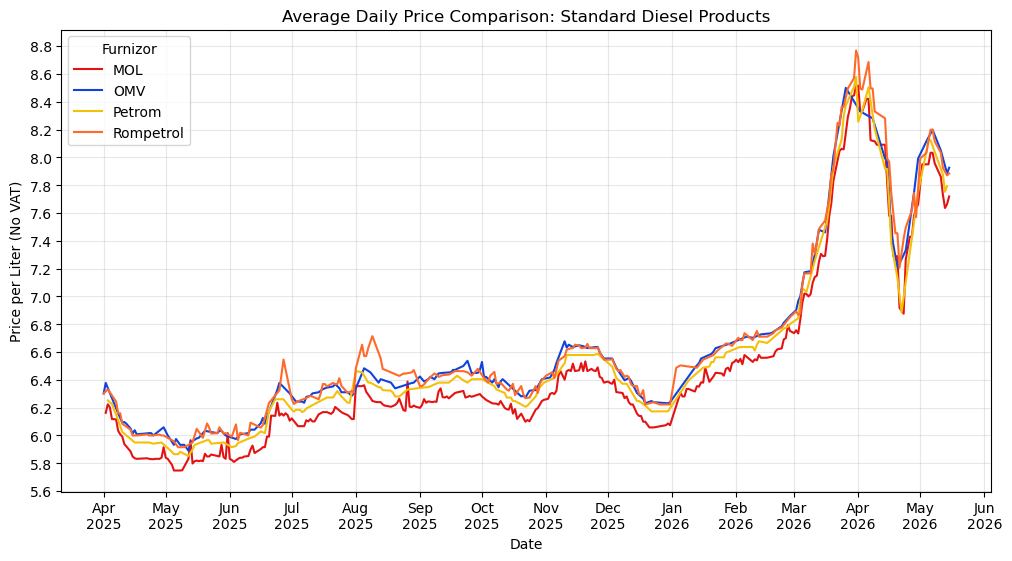

In [13]:
standard_diesel_names = ['OMV Diesel', 'Motorina standard', 'Motorina Evo D', 'EFIX MOTORINA 51']
combustibil_standard = combustibil_data[combustibil_data['Produs'].isin(standard_diesel_names)].copy()
plot_price_comparison(combustibil_standard, title_suffix="Standard")


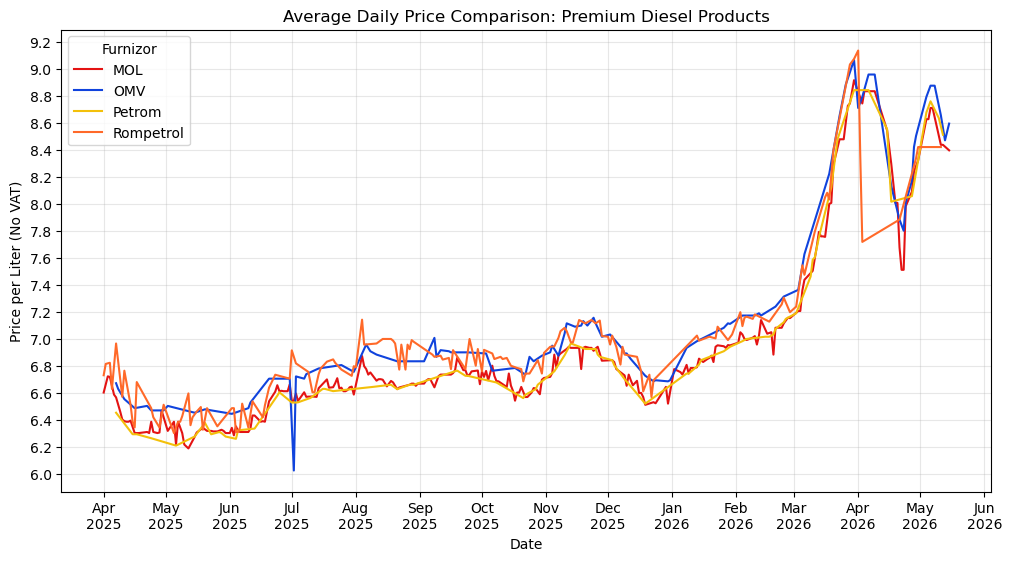

In [14]:
standard_diesel_names = ['OMV MM Diesel', 'OMV MM Diesel Artic', 'OMV MMotion95', 'Motorina Extra', 'Motorina Evo D Plus', 'EFIX S MOTORINA 55']
combustibil_standard = combustibil_data[combustibil_data['Produs'].isin(standard_diesel_names)].copy()
plot_price_comparison(combustibil_standard, title_suffix="Premium")

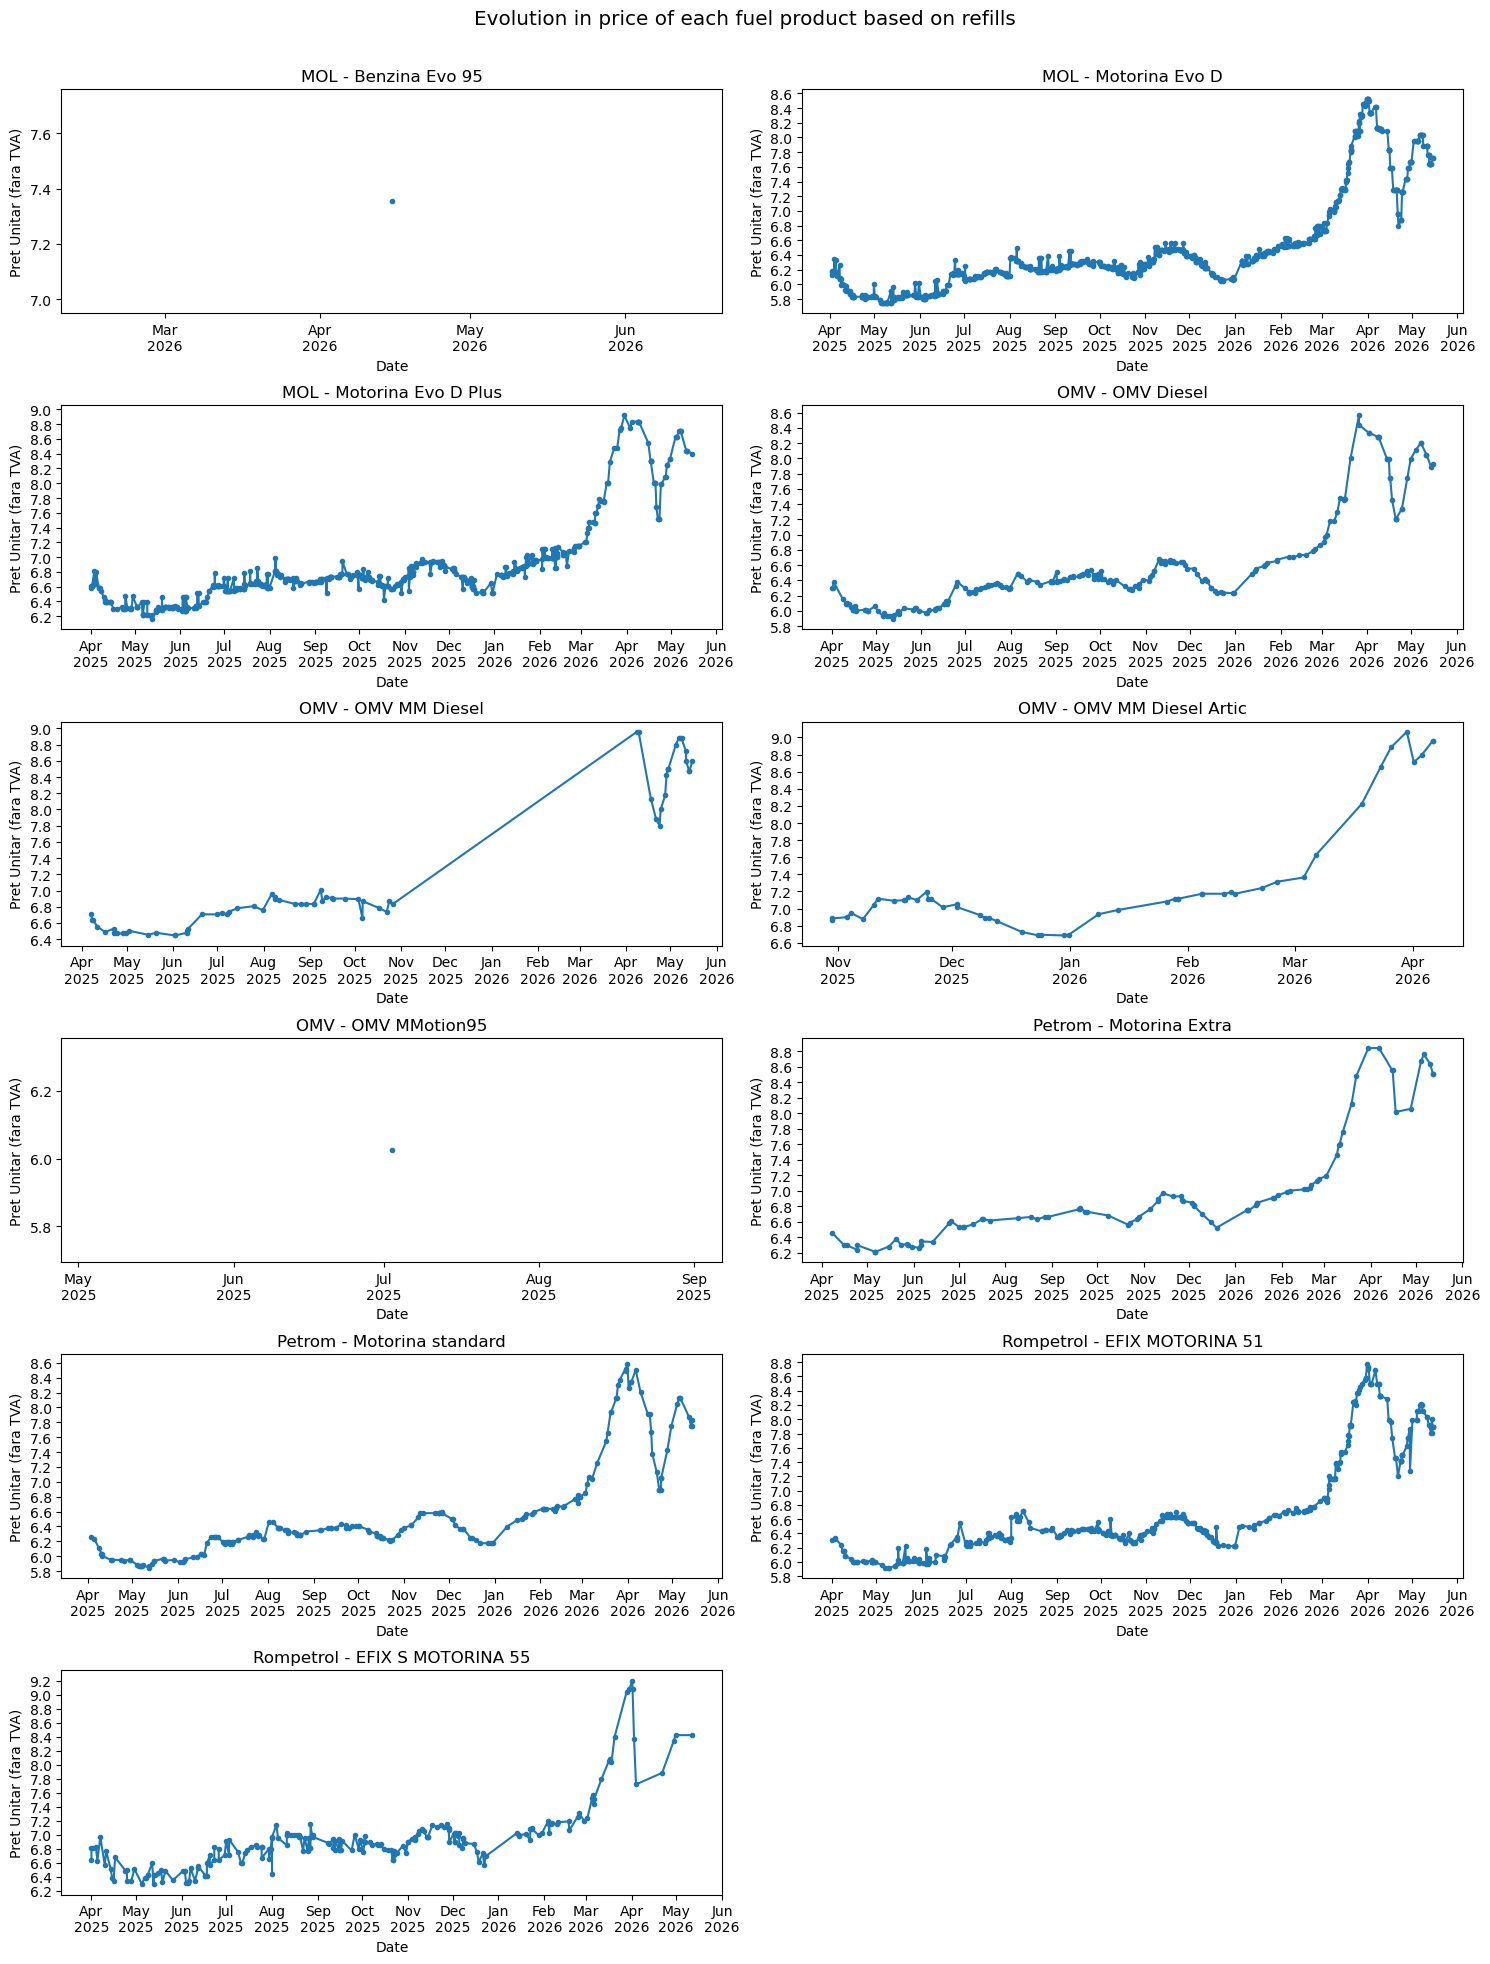

In [15]:
from math import ceil

sorted_data = combustibil_data.sort_values("Data")
figsize = (15,20)
fig = plt.figure(figsize=figsize)
st = plt.suptitle("Evolution in price of each fuel product based on refills", fontsize="x-large")



cols = 2

rows = ceil(len(sorted_data.groupby("Produs")) / cols)

i = 1

for furnizor, furnizor_data in sorted_data.groupby("Furnizor"):
    for produs, produs_data in furnizor_data.groupby("Produs"):
        ax = plt.subplot(rows, cols, i)

        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(DateFormatter('%b\n%Y'))
        ax.yaxis.set_major_locator(MultipleLocator(0.2))

        ax.plot(produs_data["Data"], produs_data["PretUnitar"], marker="o", markersize=3)
        ax.set_title(f"{furnizor} - {produs}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Pret Unitar (fara TVA)")
        plt.tight_layout()
        i += 1

fig.subplots_adjust(top=0.94)
plt.show()

## Part II: Fleet Consumption Analysis

Fleet Operaration Patterns
This shows when the drivers are most active at station

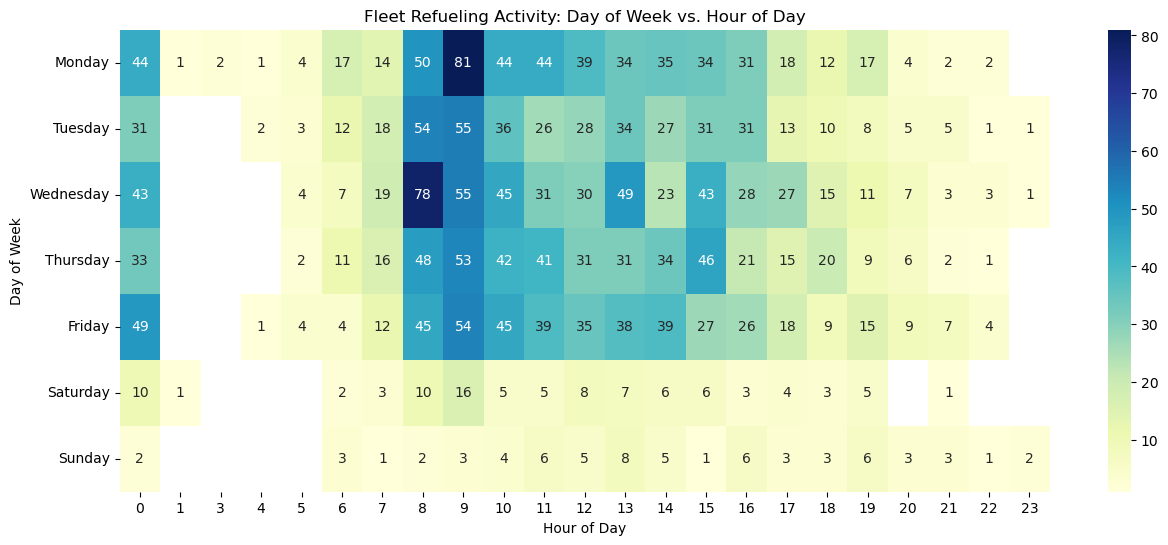

In [16]:
# Heatmap: Refueling Activity by Day and Hour
# there are some refuelings that happen at night, especially at 12 am, which can reflect 
# that the dates were not recorded correctly. Therefore just to make sure if that is the case
# i asked my boss and he agreed that those refuelings that happen at night 
# are most likely refuelings that happened during the day but the date was not recorded correctly,
#  so we can ignore those refuelings that happen at night


temp_heatmap_data = combustibil_data.copy()

temp_heatmap_data['Hour'] = temp_heatmap_data['Data'].dt.hour
temp_heatmap_data['DaysOfWeek'] = temp_heatmap_data['Data'].dt.day_name()

days_of_the_Week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = temp_heatmap_data.pivot_table(index='DaysOfWeek', columns='Hour', values='IDAlimentare', aggfunc='count').reindex(days_of_the_Week)
plt.figure(figsize=(15, 6))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt='g')
plt.title('Fleet Refueling Activity: Day of Week vs. Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

In [17]:
# to investigate this error of date parsing we will extract the name of the supplier whose refuelings happen at night
tem_date_error = temp_heatmap_data[
        pd.to_datetime(temp_heatmap_data['Data']).dt.time == pd.to_datetime('00:00:00').time()
    ]
print("Number of refuelings that happen at 12 AM: ", len(tem_date_error))

print("Suppliers with refuelings at 12 AM: ", tem_date_error['Furnizor'].unique().tolist())


Number of refuelings that happen at 12 AM:  210
Suppliers with refuelings at 12 AM:  ['Rompetrol']


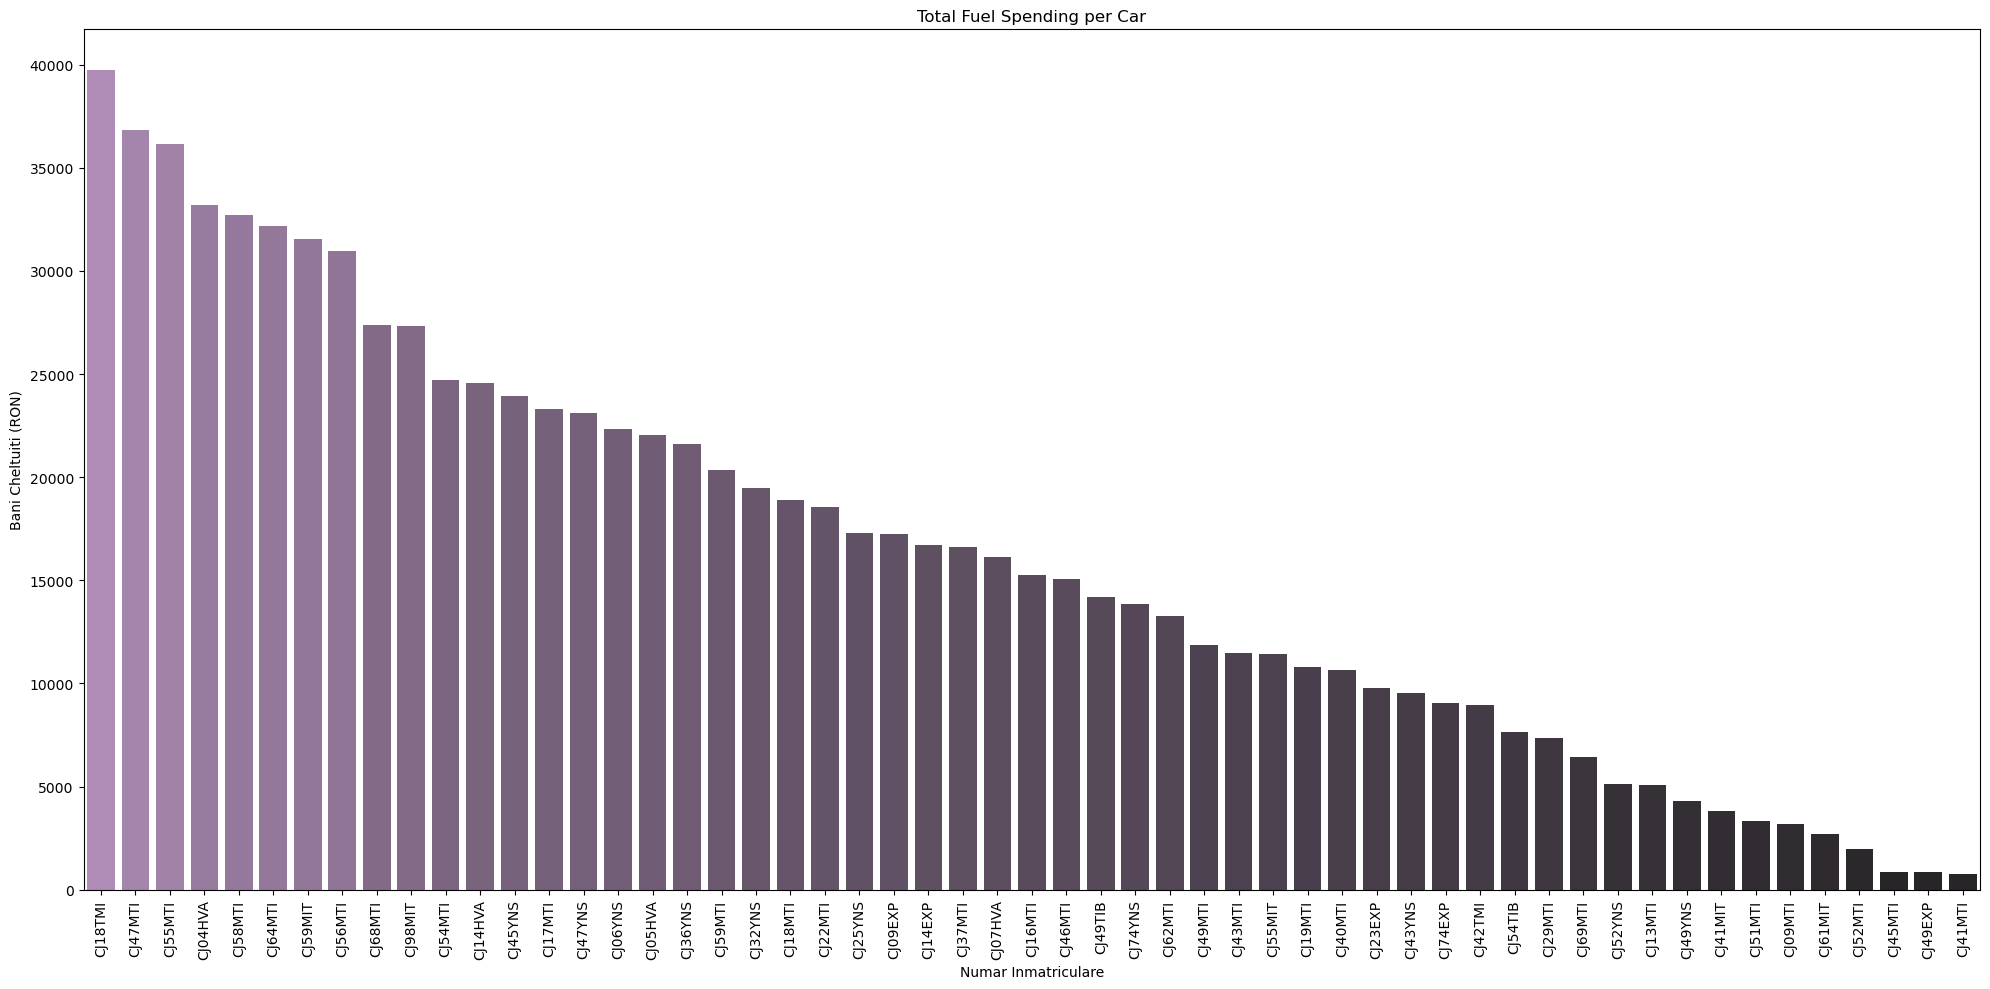

In [18]:
car_spending = combustibil_data.groupby(['NumarInmatriculare'])['Valoare'].sum().sort_values(ascending=False)

plt.figure(figsize=(20, 10))
sns.barplot(x=car_spending.index.astype(str), y=car_spending.values,palette=sns.dark_palette("#b285bc", as_cmap=True), hue=car_spending.values, legend=False)
plt.title('Total Fuel Spending per Car')
plt.ylabel('Bani Cheltuiti (RON)')
plt.xlabel('Numar Inmatriculare')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

For each car, what percentage of its total fuel coms from its most-used supplier
- brand_counts creates a dataframe by grouping the car and the supplier and counts
of transactions for each supplier
-max_loyalty takes the most visited supplier of each car

The cars with score near 100% stick to one brand

the rest of the cars: These drivers fuel wherever is most convenient.



None
None
None


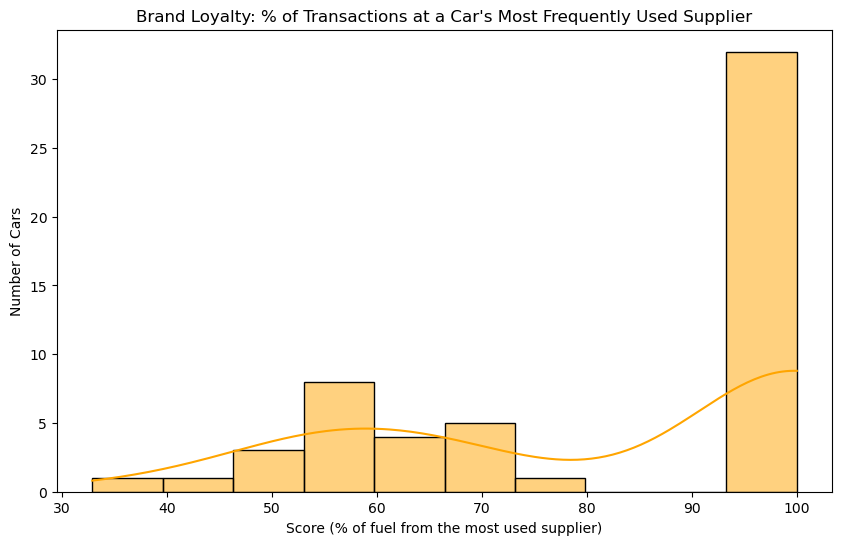

In [ ]:

brand_counts = combustibil_data.groupby(['NumarInmatriculare', 'Furnizor']).size().reset_index(name='Count')
total_fleet_counts = combustibil_data.groupby('NumarInmatriculare').size().reset_index(name='Total')
# print(brand_counts.to_csv("aaa.csv"))
# print(total_fleet_counts.to_csv("aaaa.csv"))

brand_loyalty = pd.merge(total_fleet_counts, brand_counts, on='NumarInmatriculare')
brand_loyalty['Loyalty'] = brand_loyalty['Count'] / brand_loyalty['Total'] * 100
# print(brand_loyalty.to_csv("aaaaa.csv"))

max_loyalty = brand_loyalty.groupby('NumarInmatriculare')['Loyalty'].max().reset_index()


plt.figure(figsize=(10, 6))
sns.histplot(max_loyalty['Loyalty'], bins=10, color='orange', kde=True)
plt.title('Brand Loyalty: % of Transactions at a Car\'s Most Frequently Used Supplier')
plt.xlabel('Score (% of fuel from the most used supplier)')
plt.ylabel('Number of Cars')
plt.show()

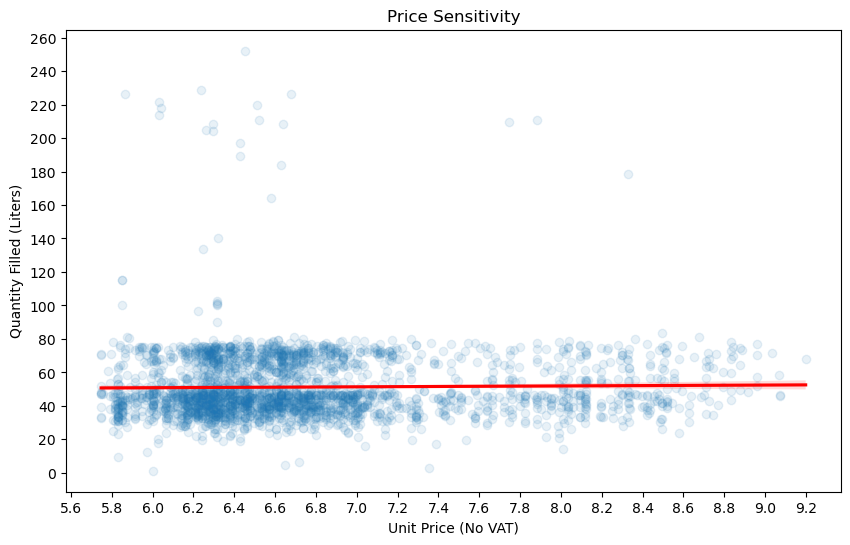

In [26]:
# This plot looks at whether your drivers change their behavior based on price.
# : In many corporate fleets, there is zero correlation (a flat line). This means drivers are "price insensitive" because they aren't paying with their own money.
# as we canse the plot appears to be dense in the left region, when it was cheaper,
# but this can be only because the prices were in that region for the majority of the time,
#  so we cannot conclude that drivers are price sensitive, but we can say that they are not price insensitive either
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=combustibil_data, x='PretUnitar', y='Cantitate', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
ax.yaxis.set_major_locator(MultipleLocator(20))
ax.xaxis.set_major_locator(MultipleLocator(0.2))
plt.title('Price Sensitivity')
plt.xlabel('Unit Price (No VAT)')
plt.ylabel('Quantity Filled (Liters)')
plt.show()